# Signature MMD Two-Sample Statistical Tests

## Numerical Examples - Poisson Processes

### Andrew Alden, Blanka Horvath, Zacharia Issa

## Table of Contents:
* [Model Setup](#env-setup)
* [Two-Sample Hypothesis Test](#two-sample)
* [Apply Scaling](#scaling)
* [Level Contributions](#lvl-contrib)
* [Relationship between Scaling, Batch Size, and Errors](#batchsize-scaling)

In [1]:
import os
os.getcwd()
path_parent = os.path.dirname(os.getcwd())
os.chdir(path_parent)

In [2]:
import math
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import pickle
from collections import defaultdict

from src.utils.helper_functions.plot_helper_functions import make_grid, golden_dimensions
from src.utils.helper_functions.global_helper_functions import get_project_root
from src.utils.plotting_functions import plot_dist, plot_level_contributions, plot_type2_error, plot_type1_error, plot_aggregate_type1_error, plot_dist_boxen
from src.mmd.distribution_functions import return_mmd_distributions, expected_type2_error, get_level_values, generate_error_probs_linear_kernel
from src.mmd.level_functions import lambda_k, level_k_contribution, mmd_est_k
from src.mmd.signature_functions import get_level_k_signatures_from_paths
from src.mmd.level_functions import lambda_k, gramda_k
from src.mmd.mmd import SigKernel, RBFKernel, LinearKernel

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


### Model Setup <a class="anchor" id="env-setup"></a>

In [4]:
dyadic_order  = 0
static_kernel = LinearKernel()

signature_kernel = SigKernel(static_kernel=static_kernel, dyadic_order=dyadic_order)

In [5]:
def sim_poisson_model(lam, num_sim, num_time_steps, T):
    time_steps = np.linspace(0, T, num_time_steps)
    dt = T / (num_time_steps - 1)
    # Increments
    increments = np.random.poisson(lam * dt, size=(num_time_steps - 1, num_sim))
    # Paths (num_time_steps, num_sim)
    paths = np.vstack([np.zeros((1, num_sim)), np.cumsum(increments, axis=0)])
    # Combine with time steps
    # path_bank shape: (num_time_steps, num_sim, 2)
    return np.concatenate((paths[:, :, None], np.repeat(np.asarray(time_steps)[:, None, None], repeats=num_sim, axis=1)), axis=2)

In [6]:
# H0 intensity
lam_0 = 10.0
# H1 intensity
lam_1 = 12.0

In [7]:
T = 1
grid_points = 20
path_bank_size = 10000

h0_path_bank = sim_poisson_model(lam_0, path_bank_size, grid_points, T)
h1_path_bank = sim_poisson_model(lam_1, path_bank_size, grid_points, T)

h0_paths = torch.transpose(torch.from_numpy(h0_path_bank), 0, 1).to(device=device, dtype=torch.float32)
h1_paths = torch.transpose(torch.from_numpy(h1_path_bank), 0, 1).to(device=device, dtype=torch.float32)

for i in range(path_bank_size):
    h0_paths[i, :, :] = h0_paths[i, :, :] - h0_paths[i, 0, :]
    h1_paths[i, :, :] = h1_paths[i, :, :] - h1_paths[i, 0, :]

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1441407/2965280724.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(p0[:, 1], (p0[:, 0] - p0[0, 0]), color="dodgerblue", alpha=0.75, label = "$\mathcal{H}_0$" if label_first else "")
/tmp/ipykernel_1441407/2965280724.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(p1[:, 1], (p1[:, 0] - p1[0, 0]), color="tomato", alpha=0.75, label = "$\mathcal{H}_1$" if label_first else "")


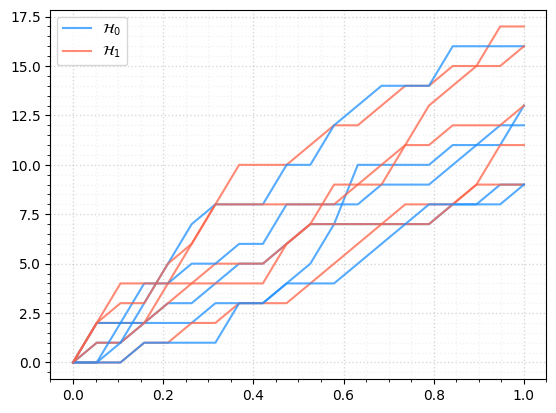

In [8]:
n_plot_paths = 5

label_first = True

for p0, p1 in zip(h0_paths[:n_plot_paths].cpu(), h1_paths[:n_plot_paths].cpu()):
    plt.plot(p0[:, 1], (p0[:, 0] - p0[0, 0]), color="dodgerblue", alpha=0.75, label = "$\mathcal{H}_0$" if label_first else "")
    plt.plot(p1[:, 1], (p1[:, 0] - p1[0, 0]), color="tomato", alpha=0.75, label = "$\mathcal{H}_1$" if label_first else "")
    label_first = False
plt.legend()
make_grid()

### Two-Sample Hypothesis Test <a class="anchor" id="two-sample"></a>

#### Unbiased

In [9]:
n_atoms   = 500
n_paths   = 128
alpha = 0.05

h0_dists, h1_dists = return_mmd_distributions(
    h0_paths, 
    h1_paths, 
    signature_kernel.compute_mmd, 
    n_atoms=n_atoms, 
    batch_size=n_paths, 
    estimator='ub'
)

plot_dist(h0_dists, h1_dists, n_atoms, alpha, 'mmd_poisson_unbiased.svg', svg=True)

  0%|          | 1/500 [00:27<3:47:53, 27.40s/it]


KeyboardInterrupt: 

In [ ]:
# Get the estimates from batches 
ks = [1, 2, 3, 4]

n_atoms = 2048
n_paths = 128

h0_Mk_vals, h1_Mk_vals = get_level_values(h0_paths, h1_paths, n_atoms, n_paths, ks, path_bank_size)
h0_Mk_vals = np.asarray(h0_Mk_vals)
h1_Mk_vals = np.asarray(h1_Mk_vals)

plot_level_contributions(h0_Mk_vals, h1_Mk_vals, n_atoms, ks, 'mmd_level_terms_poisson_unbiased.svg', svg=True, scientific=True, filter=False)

#### Biased

In [ ]:
n_atoms   = 500
n_paths   = 128
alpha = 0.05

h0_dists, h1_dists = return_mmd_distributions(
    h0_paths, 
    h1_paths, 
    signature_kernel.compute_mmd, 
    n_atoms=n_atoms, 
    batch_size=n_paths, 
    estimator='b'
)

plot_dist(h0_dists, h1_dists, n_atoms, alpha, 'mmd_poisson_biased.svg', svg=True)

### Apply Scaling <a class="anchor" id="scaling"></a>

In [ ]:
scaling = 5.5

#### Unbiased

In [ ]:
n_atoms   = 500
n_paths   = 128
alpha = 0.05

h0_dists, h1_dists = return_mmd_distributions(
    torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h0_paths[:, :, :]), 
    torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h1_paths[:, :, :]), 
    signature_kernel.compute_mmd, 
    n_atoms=n_atoms, 
    batch_size=n_paths, 
    estimator='ub'
)

plot_dist(h0_dists, h1_dists, n_atoms, alpha, f'mmd_poisson_scaling_{scaling}.svg', svg=True)

In [ ]:
# Get the estimates from batches 
ks = [1, 2, 3, 4]

n_atoms = 2048
n_paths = 128

h0_Mk_vals, h1_Mk_vals = get_level_values(torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h0_paths[:, :, :]), 
                                          torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h1_paths[:, :, :]),
                                          n_atoms, n_paths, ks, path_bank_size)
h0_Mk_vals = np.asarray(h0_Mk_vals)
h1_Mk_vals = np.asarray(h1_Mk_vals)

plot_level_contributions(h0_Mk_vals, h1_Mk_vals, n_atoms, ks, f'mmd_level_terms_poisson_scaling_{scaling}.svg', filter=False, svg=True)

#### Biased

In [ ]:
n_atoms   = 500
n_paths   = 128
alpha = 0.05

h0_dists, h1_dists = return_mmd_distributions(
    torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h0_paths[:, :, :]), 
    torch.multiply(torch.Tensor([scaling, 1]).to(device=device), h1_paths[:, :, :]), 
    signature_kernel.compute_mmd, 
    n_atoms=n_atoms, 
    batch_size=n_paths, 
    estimator='b'
)

plot_dist(h0_dists, h1_dists, n_atoms, alpha, f'mmd_poisson_scaling_{scaling}_biased.svg', svg=True)

### Relationship between Scaling, Batch Size, and Errors <a class="anchor" id="batchsize-scaling"></a>

In [ ]:
scalings = np.linspace(0, 5, 20)
n_atoms   = 100
n_paths_list   = [20, 40, 60, 120]
alpha = 0.05

In [ ]:
num_sim = 100
type1_list_unbiased, type2_list_unbiased = generate_error_probs_linear_kernel(signature_kernel,
                                                                              h0_paths,
                                                                              h1_paths,
                                                                              n_atoms, 
                                                                              n_paths_list, 
                                                                              alpha, 
                                                                              scalings,
                                                                              'ub', 
                                                                              num_sim, 
                                                                              device, 
                                                                              filename='poisson_unbiased',
                                                                              folder='PoissonData')

type1_list_biased, type2_list_biased = generate_error_probs_linear_kernel(signature_kernel, 
                                                                          h0_paths, 
                                                                          h1_paths, 
                                                                          n_atoms,
                                                                          n_paths_list, 
                                                                          alpha,
                                                                          scalings, 
                                                                          'b', 
                                                                          num_sim, 
                                                                          device, 
                                                                          filename='poisson_biased',
                                                                          folder='PoissonData')

In [ ]:
with open("PoissonData/type1error_poisson_unbiased", "rb") as fp: 
    type1_list_unbiased = pickle.load(fp)

with open("PoissonData/type2error_poisson_unbiased", "rb") as fp: 
    type2_list_unbiased = pickle.load(fp)

with open("PoissonData/type1error_poisson_biased", "rb") as fp: 
    type1_list_biased = pickle.load(fp)

with open("PoissonData/type2error_poisson_biased", "rb") as fp: 
    type2_list_biased = pickle.load(fp)

In [ ]:
plot_type2_error(type2_list_unbiased, scalings, n_paths_list, title='Unbiased')

In [ ]:
plot_type2_error(type2_list_biased, scalings, n_paths_list, title='Biased')

In [ ]:
plot_type1_error(type1_list_unbiased, scalings, n_paths_list, title='Unbiased')

In [ ]:
plot_type1_error(type1_list_biased, scalings, n_paths_list, title='Biased')